# Bank-App Session Signal Explorer

Visual review of exported **Prototype 2 bank-app** session JSON (`participantId_sNNN_sessionId.json`).

Purpose is the same as the old audit explorer: load a session and look at the raw signal graphs by eye to spot anything interesting (flat/constant fields, dropouts, saturation, odd shapes). This is **not** a feature/windowing pipeline.

In [3]:
from pathlib import Path
import json, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 160)

COLORS = {
    "x": "#2563EB", "dx": "#2563EB", "ax": "#2563EB", "agx": "#2563EB", "alpha": "#2563EB", "rotAlpha": "#2563EB",
    "y": "#DC2626", "dy": "#DC2626", "ay": "#DC2626", "agy": "#DC2626", "beta": "#DC2626", "rotBeta": "#DC2626",
    "z": "#16A34A", "az": "#16A34A", "agz": "#16A34A", "gamma": "#16A34A", "rotGamma": "#16A34A",
    "scrollLeft": "#DC2626", "scrollTop": "#2563EB", "scrollTopRatio": "#7C3AED", "maxScrollLeft": "#0891B2",
    "force": "#6B7280", "radiusX": "#2563EB", "radiusY": "#DC2626", "rotationAngle": "#7C3AED",
    "touchesCount": "#F59E0B", "pressure": "#6B7280", "width": "#7C3AED", "height": "#F59E0B",
    "movementX": "#2563EB", "movementY": "#DC2626",
    "valueLength": "#2563EB", "deltaLength": "#DC2626", "dataLength": "#F59E0B",
    "selectionStart": "#16A34A", "selectionEnd": "#7C3AED",
    "viewportWidth": "#2563EB", "viewportHeight": "#DC2626", "scale": "#7C3AED", "interval": "#6B7280",
    "distancePx": "#2563EB", "durationMs": "#DC2626", "swipeRatio": "#7C3AED",
}
DEFAULT_COLOR, TEXT, MUTED, GRID, BG = "#374151", "#111827", "#6B7280", "#E5E7EB", "white"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "axes.edgecolor": "#D1D5DB", "axes.labelcolor": TEXT, "xtick.color": TEXT, "ytick.color": TEXT,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "grid.alpha": 0.7, "font.size": 10,
})

def field_color(f): return COLORS.get(f, DEFAULT_COLOR)

def polish_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D1D5DB")
    ax.spines["bottom"].set_color("#D1D5DB")
    ax.grid(axis="y", color=GRID, alpha=0.7)
    ax.grid(axis="x", color=GRID, alpha=0.35)
    return ax


## Load data

Put your exported session JSON in `./data/raw_json/` (or `./data/`, or next to this notebook), or set `FILES` to an explicit list of paths. Multiple files are fine; the time-series plots use one `FOCUS_SESSION` at a time so traces don't get mixed together.

In [4]:
CANDIDATE_DIRS = [Path("data/raw_json"), Path("data"), Path(".")]
FILES = None   # e.g. [Path("pG5G4MS_s041_xxx.json")] to pick specific files

def find_session_files():
    if FILES:
        return [Path(p) for p in FILES]
    for d in CANDIDATE_DIRS:
        if d.exists():
            found = sorted(d.glob("*.json"))
            if found:
                return found
    return []

def is_bank_session(obj):
    return isinstance(obj, dict) and "events" in obj and "taskSummary" in obj and "fieldSummary" not in obj

def flatten_events(obj, skey):
    rows = []
    for e in obj.get("events", []):
        row = {k: v for k, v in e.items() if k != "payload"}
        row.update(e.get("payload") or {})
        row["sessionKey"] = skey
        rows.append(row)
    return rows

paths = find_session_files()
event_rows, session_rows, task_rows = [], [], []
for p in paths:
    try:
        obj = json.load(open(p))
    except Exception as ex:
        print("Skip", p.name, "->", ex); continue
    if not is_bank_session(obj):
        print("Skip", p.name, "-> not a bank-app session (no taskSummary / looks like audit data)"); continue
    skey = "{}_s{}".format(obj.get("participantId"), obj.get("sessionIndex"))
    event_rows += flatten_events(obj, skey)
    qs = obj.get("qualitySummary", {}) or {}
    ctx = obj.get("context", {}) or {}
    dev = obj.get("device", {}) or {}
    perms = obj.get("permissions", {}) or {}
    session_rows.append({
        "sessionKey": skey, "file": p.name,
        "participantId": obj.get("participantId"), "sessionIndex": obj.get("sessionIndex"),
        "appMode": obj.get("appMode"), "durationS": round((obj.get("sessionDurationMs") or 0) / 1000, 1),
        "events": len(obj.get("events", [])), "tasks": len(obj.get("taskSummary", [])),
        "completedNormally": obj.get("completedNormally"),
        "usable": qs.get("usableForSignalExtraction"), "warnings": qs.get("warnings"),
        "devicePlatform": ctx.get("devicePlatform"), "deviceModel": ctx.get("deviceModel"),
        "deviceFamily": dev.get("deviceFamily"), "platform": dev.get("platform"),
        "motionPerm": perms.get("motion"), "orientationPerm": perms.get("orientation"),
        "ua": (dev.get("userAgent") or "")[:55],
    })
    for t in obj.get("taskSummary", []):
        task_rows.append({"sessionKey": skey, **t})

events_df = pd.DataFrame(event_rows)
sessions_df = pd.DataFrame(session_rows)
tasks_df = pd.DataFrame(task_rows)

if events_df.empty:
    print("No bank-app session JSON found. Put *.json in ./data/raw_json (or set FILES) and re-run.")
    FOCUS_SESSION = None
    fdf = pd.DataFrame(columns=["kind", "tRelMs", "activeArea"])
else:
    print("Loaded {} session(s), {} events".format(len(sessions_df), len(events_df)))
    print("Sessions available:", list(sessions_df["sessionKey"]))
    FOCUS_SESSION = sessions_df["sessionKey"].iloc[0]
    fdf = events_df[events_df["sessionKey"] == FOCUS_SESSION].copy()
    print("FOCUS_SESSION =", FOCUS_SESSION, "(edit this var + re-run cells below to switch)")


Loaded 1 session(s), 9392 events
Sessions available: ['pG5G4MS_s42']
FOCUS_SESSION = pG5G4MS_s42 (edit this var + re-run cells below to switch)


## Session overview

In [5]:
display(sessions_df)

,sessionKey,file,participantId,sessionIndex,appMode,durationS,events,tasks,completedNormally,usable,warnings,devicePlatform,deviceModel,deviceFamily,platform,motionPerm,orientationPerm,ua
0,pG5G4MS_s42,pG5G4MS_s042_284ec0d05a214f81ba49faba7738cbd0.json,pG5G4MS,42,collection,176.1,9392,26,True,True,[],iphone,iphone_17,mobile,iPhone,granted,granted,Mozilla/5.0 (iPhone; CPU iPhone OS 18_7 like Mac OS X)


## Event counts (focused session)

,kind,count
0,devicemotion,2440
1,deviceorientation,2425
2,touchmove,1712
3,scroll,786
4,carousel_scroll,294
5,window_scroll,259
6,pointermove,246
7,pointerdown,130
8,touchstart,130
9,touchend,130


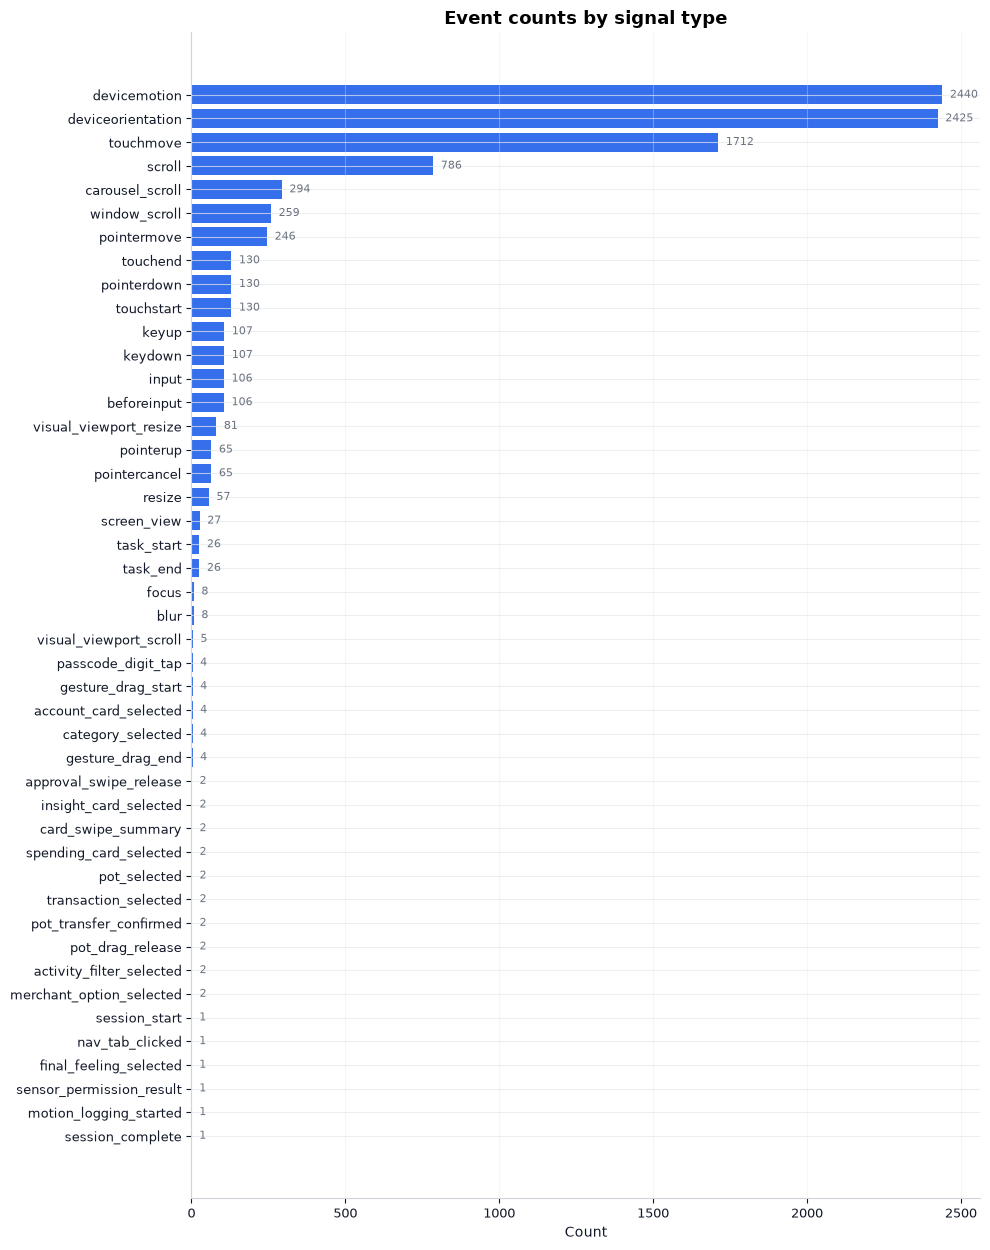

In [6]:
if fdf.empty:
    print("No events to plot.")
else:
    counts = fdf["kind"].value_counts().rename_axis("kind").reset_index(name="count")
    display(counts)
    plot_df = counts.sort_values("count", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(5, len(plot_df) * 0.28)))
    bars = ax.barh(plot_df["kind"], plot_df["count"], color="#2563EB", alpha=0.92)
    ax.set_title("Event counts by signal type")
    ax.set_xlabel("Count"); polish_ax(ax)
    for bar in bars:
        w = bar.get_width()
        ax.text(w + max(plot_df["count"]) * 0.01, bar.get_y() + bar.get_height()/2, str(int(w)),
                va="center", ha="left", fontsize=8, color=MUTED)
    plt.tight_layout(); plt.show()

## Field availability & quality (computed from raw events)

The bank-app JSON has no precomputed `fieldSummary`, so this is derived here: per `(kind, field)` non-null fraction, unique count, and an `allZeroish` flag that catches dead constant-zero fields (e.g. iOS `radiusY` / `rotationAngle`).

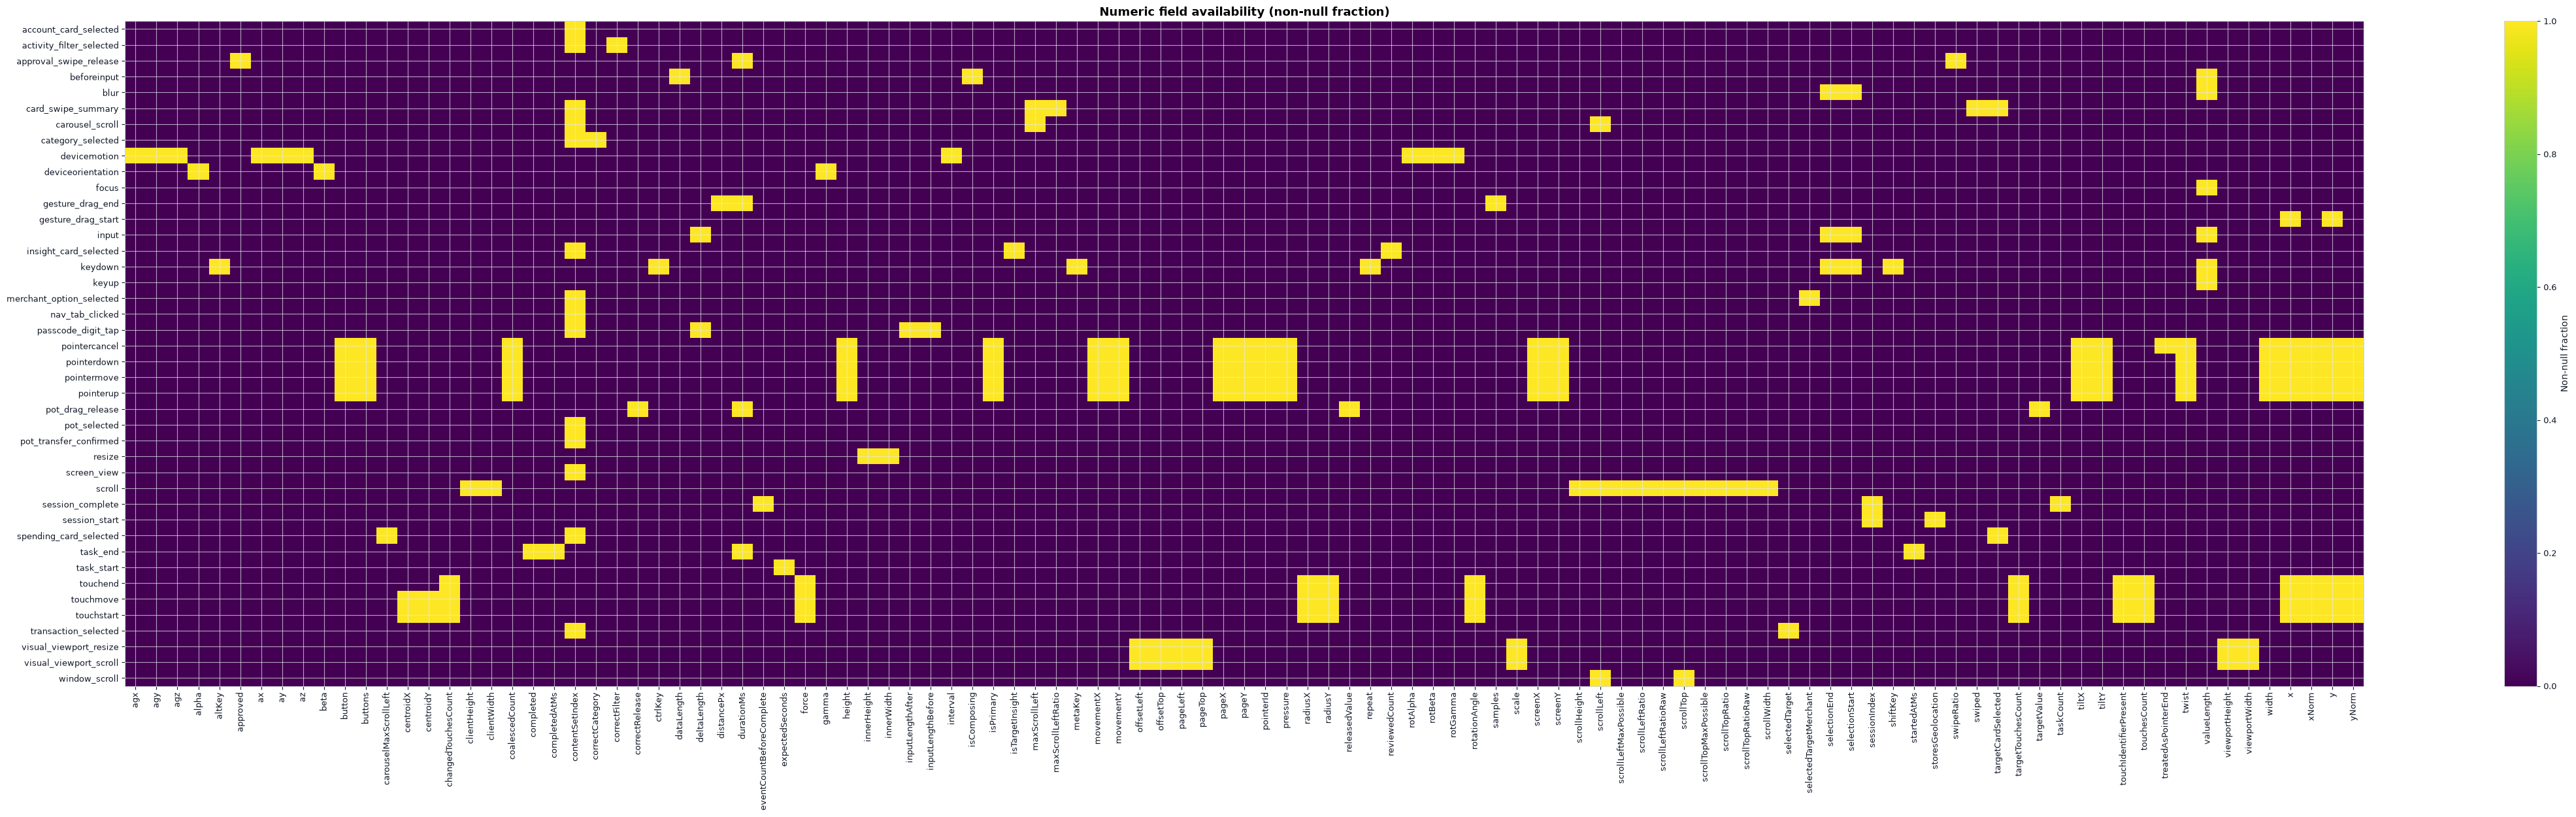

,kind,field,count,nonNullFrac,uniqueCount,allZeroish,min,max
0,account_card_selected,accountId,4,1.0,3,False,NaN,NaN
1,account_card_selected,activeArea,4,1.0,1,False,NaN,NaN
2,account_card_selected,activeBaseTaskId,4,1.0,2,False,NaN,NaN
3,account_card_selected,activeTaskId,4,1.0,2,False,NaN,NaN
4,account_card_selected,componentId,4,1.0,3,False,NaN,NaN
...,...,...,...,...,...,...,...,...
456,window_scroll,activeArea,259,1.0,5,False,NaN,NaN
457,window_scroll,screenId,259,1.0,19,False,NaN,NaN
458,window_scroll,scrollLeft,259,1.0,1,True,0.0,0.0
459,window_scroll,scrollTop,259,1.0,134,False,0.0,655.0


In [7]:
def compute_field_stats(df):
    skip = {"sessionKey", "kind", "tRelMs", "t", "ms", "tISO", "timestampIso", "taskIndex", "instructionArea"}
    rows = []
    for kind, g in df.groupby("kind"):
        n = len(g)
        for col in g.columns:
            if col in skip:
                continue
            s = g[col]
            nn = int(s.notna().sum())
            if nn == 0:
                continue
            try:
                num = pd.to_numeric(s, errors="coerce")
            except (TypeError, ValueError):
                num = pd.Series(np.nan, index=s.index)
            is_num = int(num.notna().sum()) > 0
            allzero = bool(is_num and np.nanmax(np.abs(num.dropna().values)) < 1e-9) if is_num else False
            try:
                uniq = int(s.nunique(dropna=True))
            except TypeError:
                uniq = int(s.dropna().map(lambda v: str(v)).nunique())
            rows.append({
                "kind": kind, "field": col, "count": n,
                "nonNullFrac": round(nn / n, 3), "uniqueCount": uniq,
                "allZeroish": allzero,
                "min": (round(float(np.nanmin(num)), 3) if is_num else None),
                "max": (round(float(np.nanmax(num)), 3) if is_num else None),
            })
    return pd.DataFrame(rows)

field_df = compute_field_stats(fdf) if not fdf.empty else pd.DataFrame()

if field_df.empty:
    print("No events to summarise.")
else:
    num_fields = field_df[field_df["min"].notna()]
    heat = num_fields.pivot_table(index="kind", columns="field", values="nonNullFrac", aggfunc="max").fillna(0)
    if heat.size:
        fig, ax = plt.subplots(figsize=(max(12, len(heat.columns) * 0.42), max(5, len(heat) * 0.30)))
        im = ax.imshow(heat.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
        ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns, rotation=90)
        ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index)
        ax.set_title("Numeric field availability (non-null fraction)")
        cbar = plt.colorbar(im, ax=ax); cbar.set_label("Non-null fraction")
        plt.tight_layout(); plt.show()
    display(field_df.sort_values(["kind", "field"]).reset_index(drop=True))

## Keep / maybe / drop hint (per field)

Quick heuristic to flag dead fields by eye. `drop` = constant-zero or near-constant; `keep` = well-populated and varied; `maybe` = present but low-variation.

In [8]:
def decide(row):
    if row["allZeroish"]:
        return "drop"
    if row["nonNullFrac"] >= 0.8 and row["uniqueCount"] >= 10:
        return "keep"
    if row["nonNullFrac"] >= 0.2 and row["uniqueCount"] >= 3:
        return "maybe"
    return "drop"

if field_df.empty:
    print("No field stats.")
else:
    dd = field_df.copy()
    dd["decision"] = dd.apply(decide, axis=1)
    order = {"keep": 0, "maybe": 1, "drop": 2}
    dd["_o"] = dd["decision"].map(order)
    display(dd.sort_values(["_o", "kind", "field"]).drop(columns="_o").reset_index(drop=True))

,kind,field,count,nonNullFrac,uniqueCount,allZeroish,min,max,decision
0,beforeinput,valueLength,106,1.0,34,False,0.000,33.000,keep
1,carousel_scroll,maxScrollLeft,294,1.0,244,False,17.000,1848.000,keep
2,carousel_scroll,scrollLeft,294,1.0,274,False,17.000,1848.000,keep
3,devicemotion,agx,2440,1.0,2088,False,-2.252,2.415,keep
4,devicemotion,agy,2440,1.0,1806,False,-12.345,-6.734,keep
...,...,...,...,...,...,...,...,...,...
456,visual_viewport_scroll,pageLeft,5,1.0,1,True,0.000,0.000,drop
457,visual_viewport_scroll,scale,5,1.0,1,False,1.000,1.000,drop
458,visual_viewport_scroll,viewportHeight,5,1.0,1,False,815.000,815.000,drop
459,visual_viewport_scroll,viewportWidth,5,1.0,1,False,430.000,430.000,drop


## Plot helpers

In [9]:
def available_cols(df, cols):
    return [c for c in cols if c in df.columns and df[c].notna().sum() > 0]

def multi_line_plot(df, cols, title, x="tRelMs"):
    use = available_cols(df, cols)
    if df.empty or not use:
        print("Skipped (no data):", title); return
    fig, ax = plt.subplots(figsize=(11, 3.8))
    d = df.sort_values(x)
    for c in use:
        ax.plot(d[x], d[c], label=c, color=field_color(c), linewidth=1.3, alpha=0.95)
    ax.set_title(title); ax.set_xlabel("Time since start (ms)")
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6)); polish_ax(ax)
    ax.legend(ncol=min(5, len(use)), frameon=False, loc="best")
    plt.tight_layout(); plt.show()

def hist_plot(df, col, title, bins=40):
    if df.empty or col not in df.columns or df[col].notna().sum() == 0:
        print("Skipped (no data):", title); return
    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    ax.hist(pd.to_numeric(df[col], errors="coerce").dropna(), bins=bins,
            color=field_color(col), alpha=0.9, edgecolor="white", linewidth=0.6)
    ax.set_title(title); ax.set_xlabel(col); ax.set_ylabel("Count"); polish_ax(ax)
    plt.tight_layout(); plt.show()

def plot_family(df, title, cols, show_table=True):
    print(title + ":", len(df), "rows")
    use = available_cols(df, cols)
    if not use:
        print("  no plottable columns found."); return
    if show_table:
        display(df[["kind", "tRelMs"] + use].head(15))
    multi_line_plot(df, use, title + ": over time")
    for c in use:
        hist_plot(df, c, title + ": " + c + " distribution")

## Pointer and touch

Pointer signals: 441 rows


,kind,tRelMs,x,y,pressure,width,height,movementX,movementY
63,pointerdown,2940,225.00,498.33,0.0,48.4156,48.4156,0.0,0.0
67,pointerup,3001,225.00,498.33,0.0,0.0000,0.0000,0.0,0.0
74,pointerdown,3123,75.67,502.67,0.0,48.4156,48.4156,0.0,0.0
80,pointerup,3234,75.67,502.67,0.0,0.0000,0.0000,0.0,0.0
99,pointerdown,3672,226.33,439.00,0.0,48.4156,48.4156,0.0,0.0
103,pointerup,3718,226.33,439.00,0.0,0.0000,0.0000,0.0,0.0
120,pointerdown,4137,344.67,567.33,0.0,48.4156,48.4156,0.0,0.0
124,pointerup,4200,344.67,567.33,0.0,0.0000,0.0000,0.0,0.0
253,pointerdown,7648,36.00,739.33,0.0,24.2078,24.2078,0.0,0.0
259,pointerup,7745,36.00,739.33,0.0,0.0000,0.0000,0.0,0.0


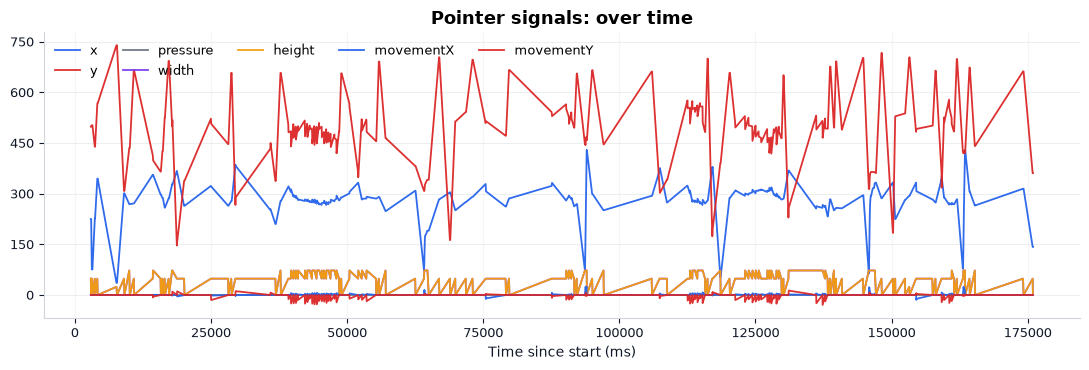

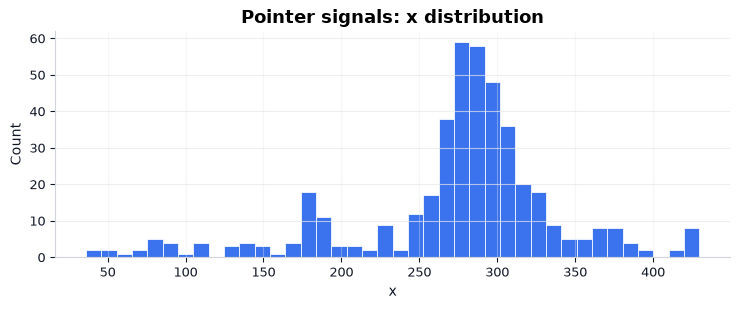

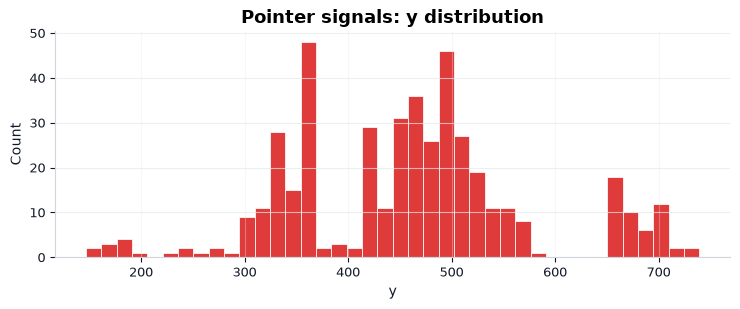

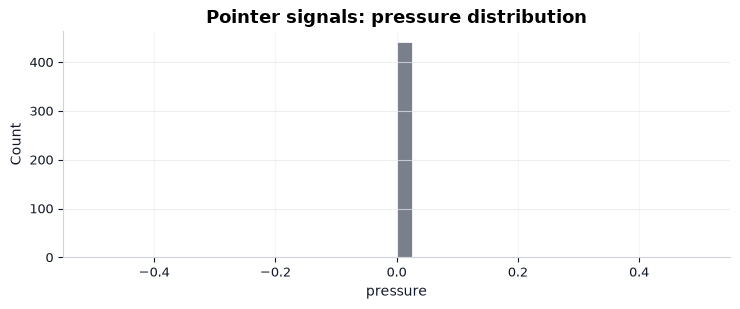

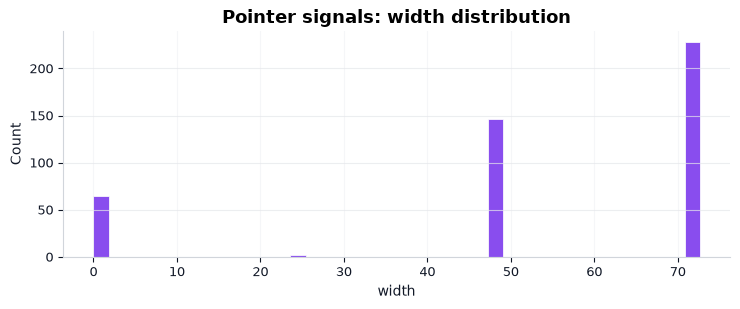

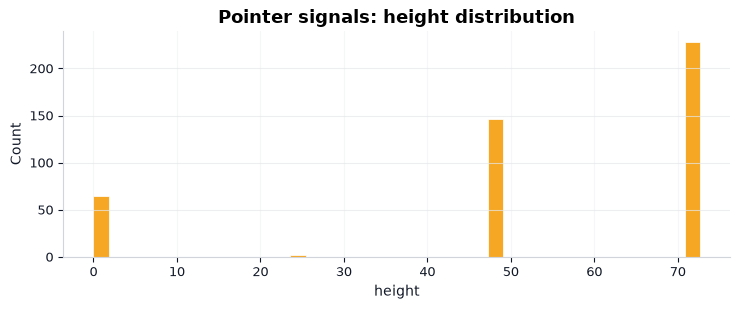

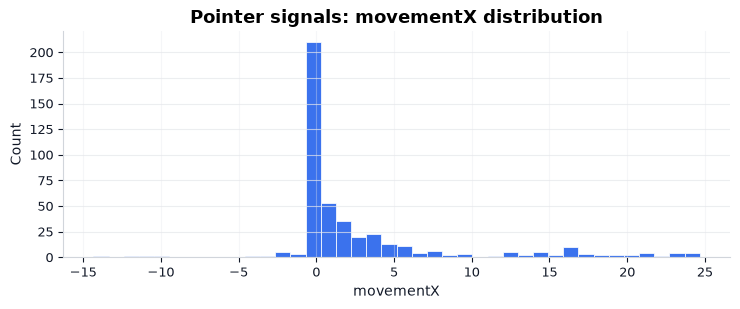

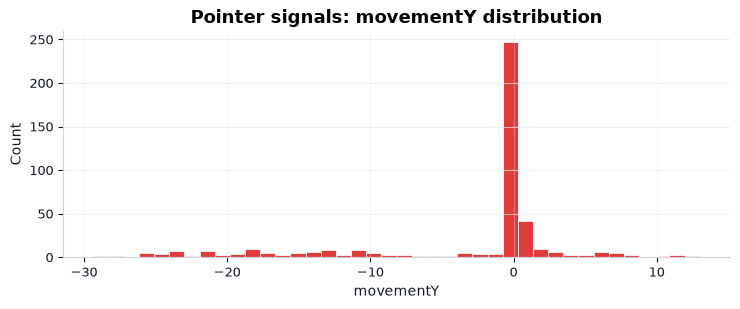

Touch signals: 1972 rows


,kind,tRelMs,x,y,force,radiusX,radiusY,rotationAngle,touchesCount
64,touchstart,2943,225.00,498.33,24.2078,24.2078,0.0,0.0,1.0
68,touchend,3002,225.00,498.33,0.0000,24.2078,0.0,0.0,0.0
75,touchstart,3123,75.67,502.67,24.2078,24.2078,0.0,0.0,1.0
81,touchend,3234,75.67,502.67,0.0000,24.2078,0.0,0.0,0.0
100,touchstart,3672,226.33,439.00,24.2078,24.2078,0.0,0.0,1.0
104,touchend,3718,226.33,439.00,0.0000,24.2078,0.0,0.0,0.0
121,touchstart,4137,344.67,567.33,24.2078,24.2078,0.0,0.0,1.0
125,touchend,4200,344.67,567.33,0.0000,24.2078,0.0,0.0,0.0
254,touchstart,7648,36.00,739.33,12.1039,12.1039,0.0,0.0,1.0
260,touchend,7745,36.00,739.33,0.0000,12.1039,0.0,0.0,0.0


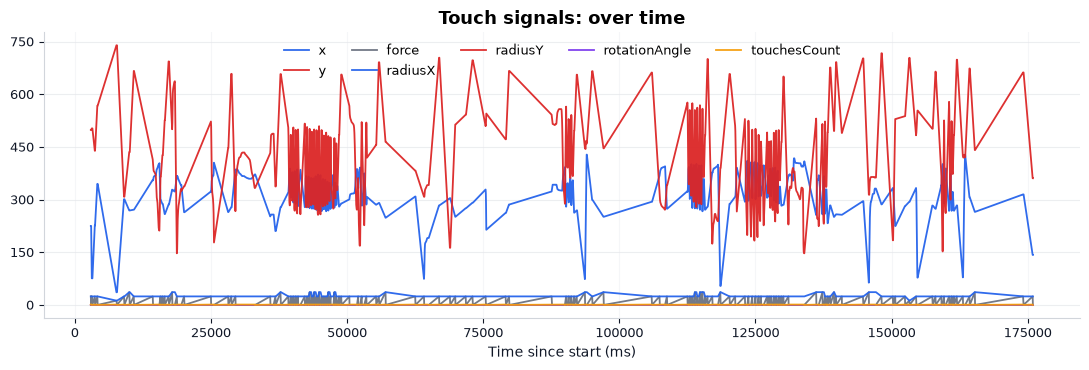

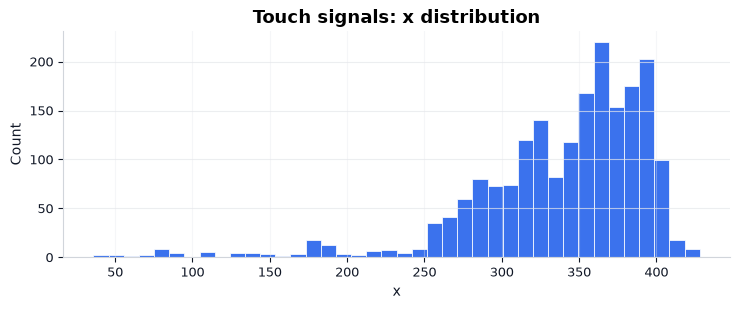

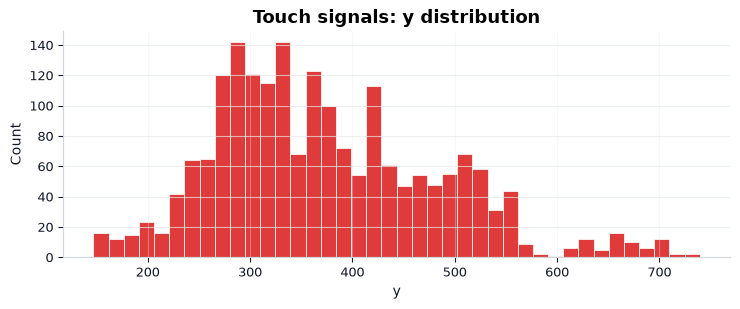

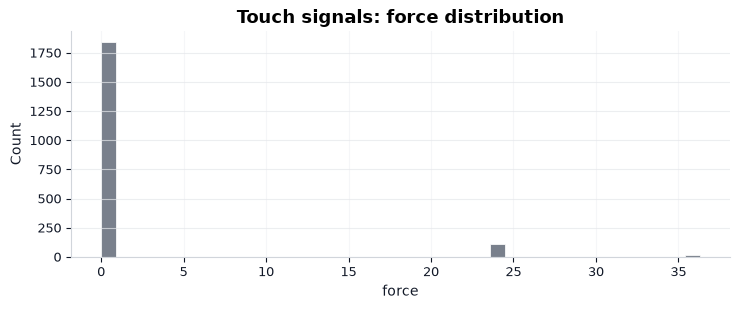

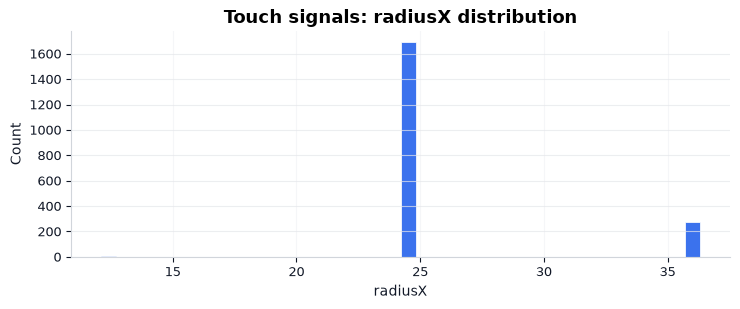

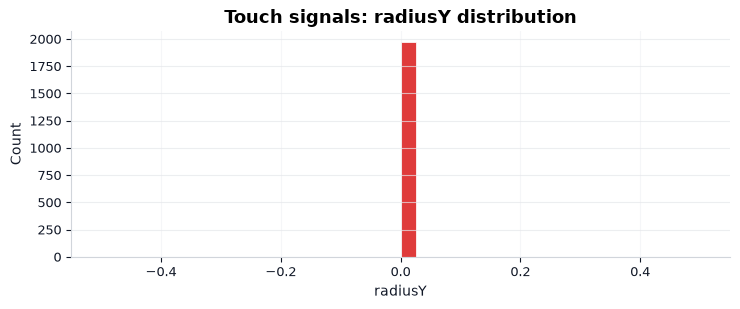

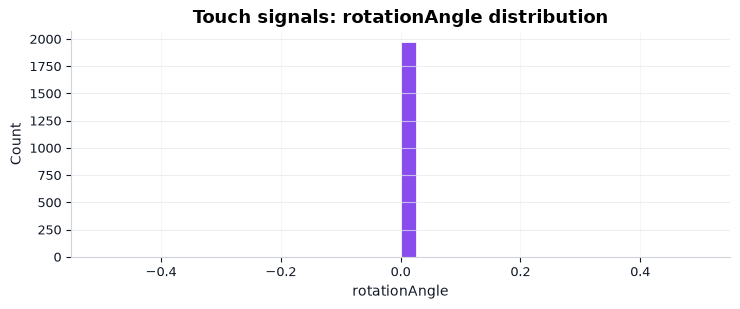

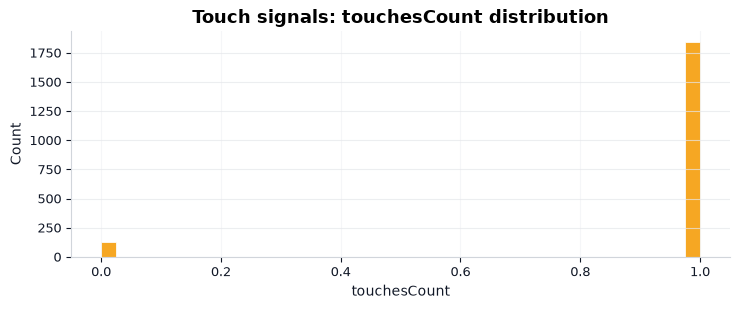

In [10]:
pointer = fdf[fdf["kind"].isin(["pointerdown", "pointermove", "pointerup"])].copy()
touch = fdf[fdf["kind"].isin(["touchstart", "touchmove", "touchend"])].copy()

plot_family(pointer, "Pointer signals", ["x", "y", "pressure", "width", "height", "movementX", "movementY"])
plot_family(touch, "Touch signals", ["x", "y", "force", "radiusX", "radiusY", "rotationAngle", "touchesCount"])

## Scroll and viewport

Scroll (vertical feeds): 786 rows


,kind,tRelMs,scrollTop,scrollLeft,scrollTopRatio
753,scroll,17952,-12.0,0.0,0.0
755,scroll,17983,-29.0,0.0,0.0
758,scroll,18017,-35.0,0.0,0.0
761,scroll,18050,-38.0,0.0,0.0
764,scroll,18083,-40.0,0.0,0.0
767,scroll,18116,-42.0,0.0,0.0
771,scroll,18166,-44.0,0.0,0.0
774,scroll,18199,-46.0,0.0,0.0
777,scroll,18233,-47.0,0.0,0.0
782,scroll,18299,-48.0,0.0,0.0


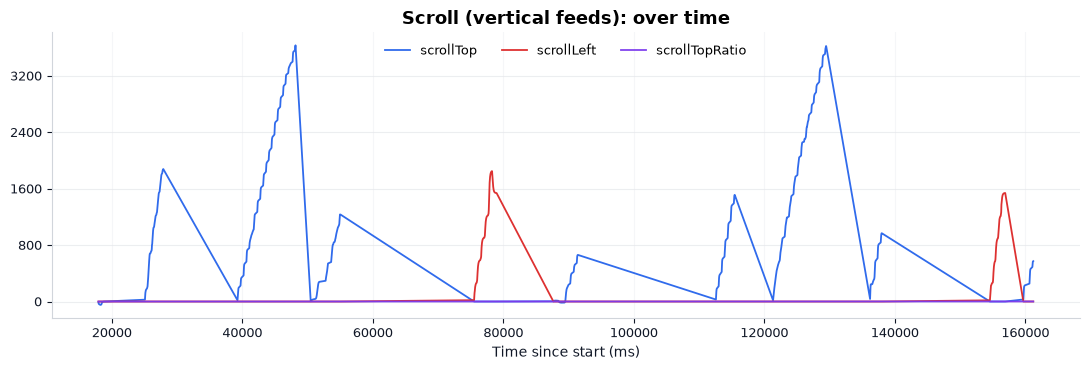

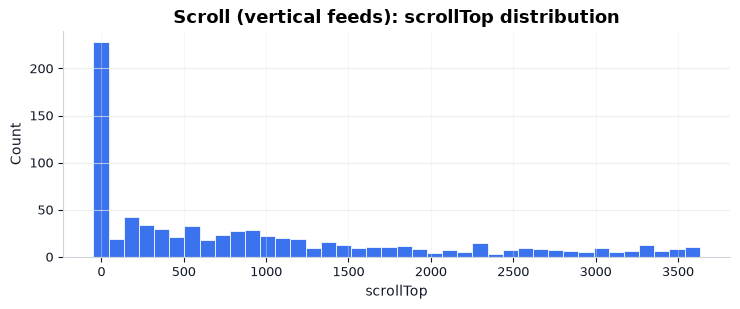

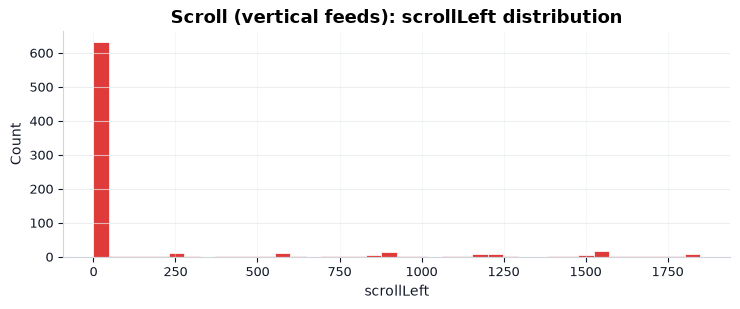

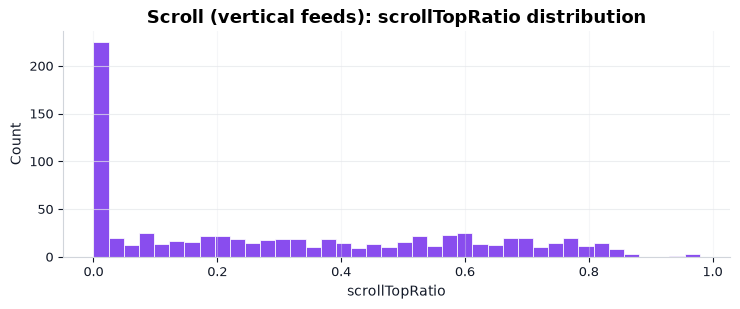

Carousel (horizontal) scroll: 294 rows


,kind,tRelMs,scrollLeft,maxScrollLeft
3831,carousel_scroll,75519,19.0,19.0
3833,carousel_scroll,75536,49.0,49.0
3836,carousel_scroll,75552,80.0,80.0
3839,carousel_scroll,75572,93.0,93.0
3841,carousel_scroll,75585,121.0,121.0
3843,carousel_scroll,75618,144.0,144.0
3844,carousel_scroll,75634,164.0,164.0
3846,carousel_scroll,75653,181.0,181.0
3847,carousel_scroll,75667,195.0,195.0
3849,carousel_scroll,75684,207.0,207.0


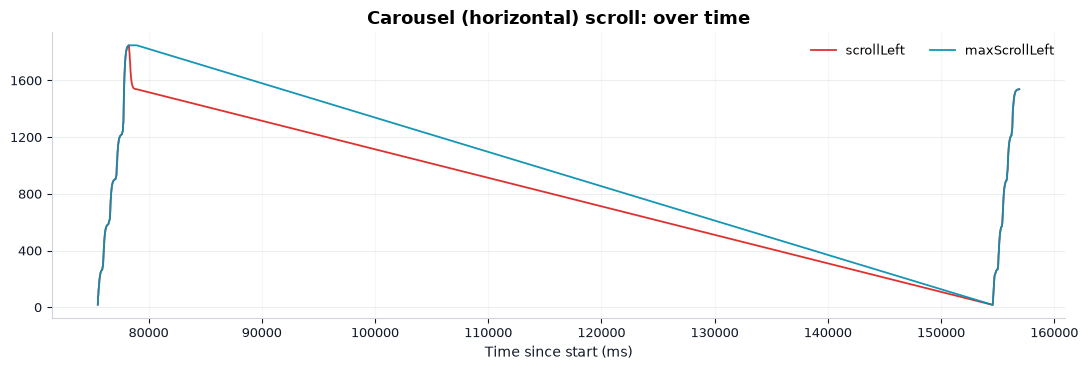

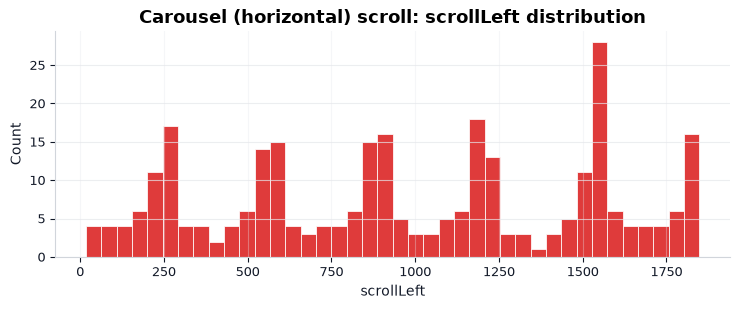

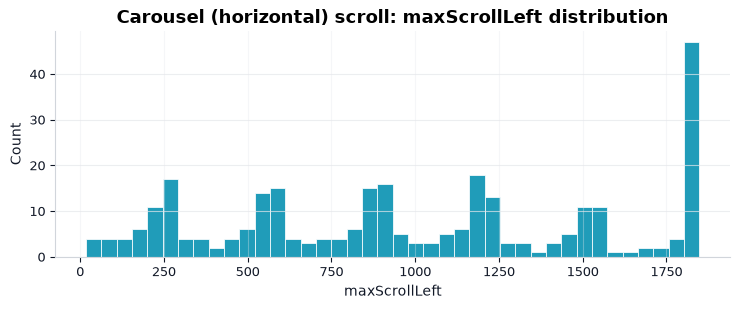

Viewport: 143 rows


,kind,tRelMs,viewportWidth,viewportHeight,scale
9,visual_viewport_scroll,1457,430.0,815.0,1.0
10,resize,1468,NaN,NaN,NaN
528,resize,14416,NaN,NaN,NaN
529,visual_viewport_resize,14416,430.0,777.0,1.0
533,resize,14453,NaN,NaN,NaN
535,resize,14473,NaN,NaN,NaN
536,visual_viewport_resize,14473,430.0,782.0,1.0
540,resize,14506,NaN,NaN,NaN
549,resize,14602,NaN,NaN,NaN
553,visual_viewport_resize,14652,430.0,784.0,1.0


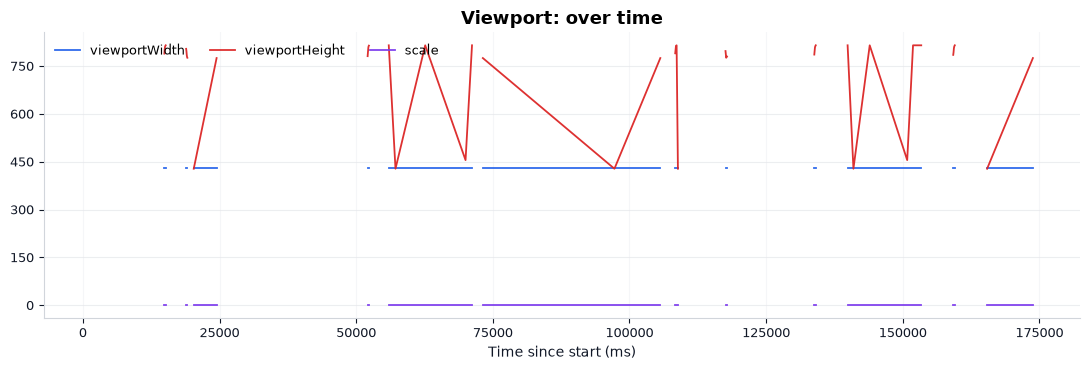

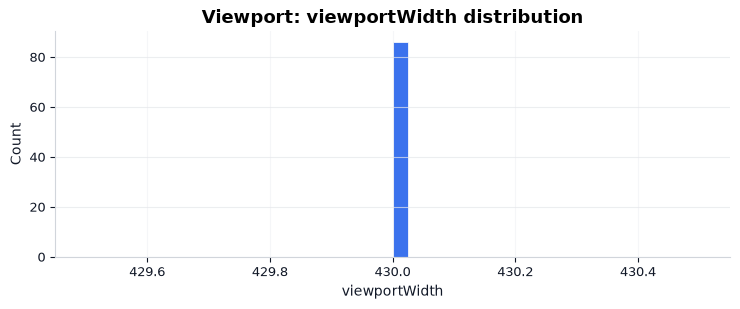

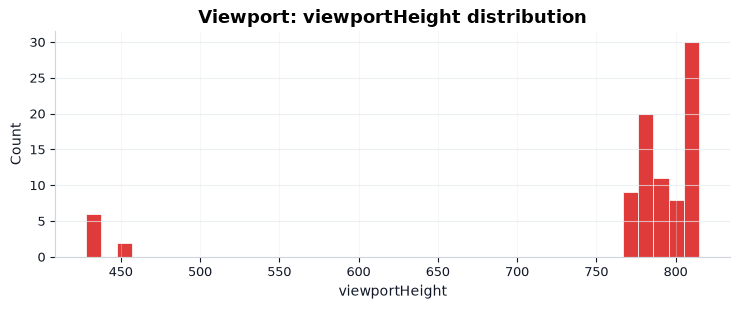

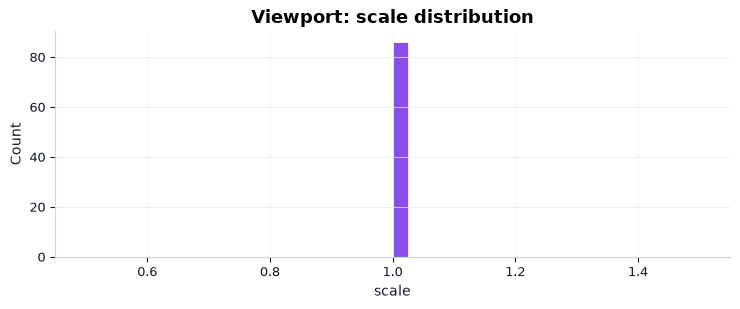

In [11]:
scroll = fdf[fdf["kind"] == "scroll"].copy()
carousel = fdf[fdf["kind"] == "carousel_scroll"].copy()
viewport = fdf[fdf["kind"].isin(["visual_viewport_resize", "visual_viewport_scroll", "resize"])].copy()

plot_family(scroll, "Scroll (vertical feeds)", ["scrollTop", "scrollLeft", "scrollTopRatio"])
plot_family(carousel, "Carousel (horizontal) scroll", ["scrollLeft", "maxScrollLeft"])
plot_family(viewport, "Viewport", ["viewportWidth", "viewportHeight", "scale"])

## Keyboard / input

Raw typed text is never stored; these are timing, length and class signals only.

Keyboard/input events: 426


,kind,count
0,keydown,107
1,keyup,107
2,beforeinput,106
3,input,106


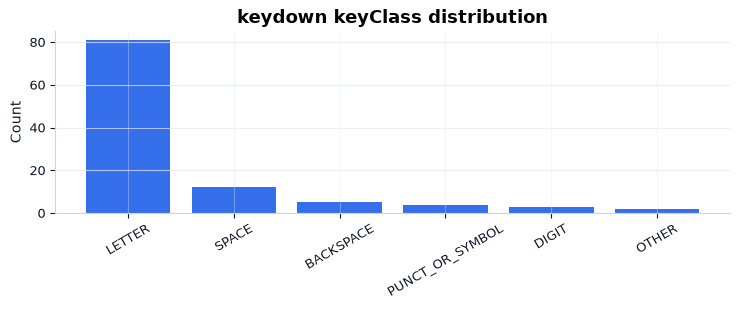

Keyboard/input numeric signals: 426 rows


,kind,tRelMs,valueLength,deltaLength,dataLength,selectionStart,selectionEnd
981,keydown,22633,0.0,NaN,NaN,0.0,0.0
982,beforeinput,22642,0.0,NaN,1.0,NaN,NaN
983,input,22649,1.0,1.0,NaN,1.0,1.0
984,keyup,22650,1.0,NaN,NaN,NaN,NaN
991,keydown,22848,1.0,NaN,NaN,1.0,1.0
994,beforeinput,22855,1.0,NaN,1.0,NaN,NaN
995,input,22856,2.0,1.0,NaN,2.0,2.0
996,keyup,22858,2.0,NaN,NaN,NaN,NaN
999,keydown,22965,2.0,NaN,NaN,2.0,2.0
1002,beforeinput,22972,2.0,NaN,1.0,NaN,NaN


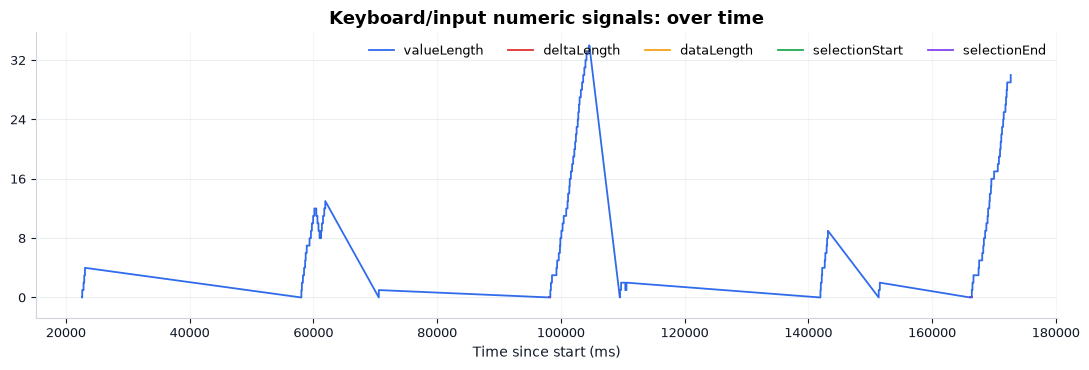

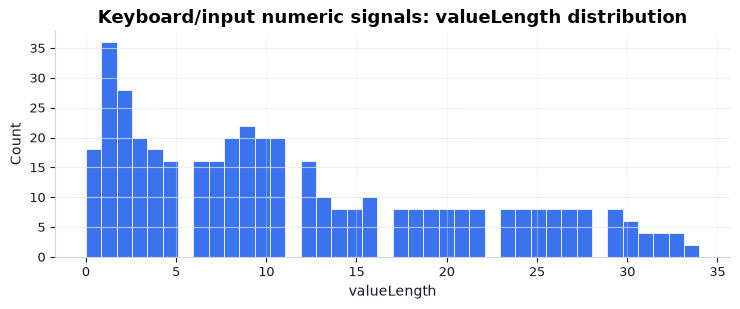

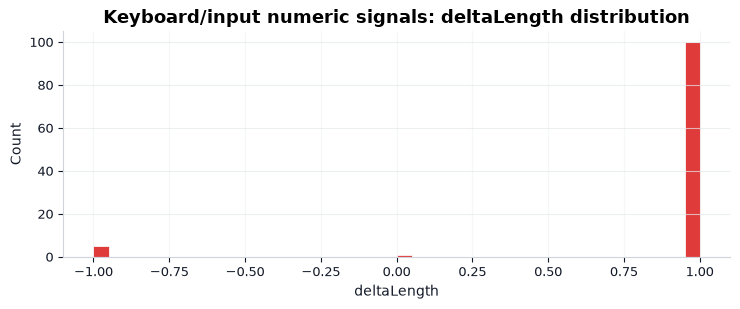

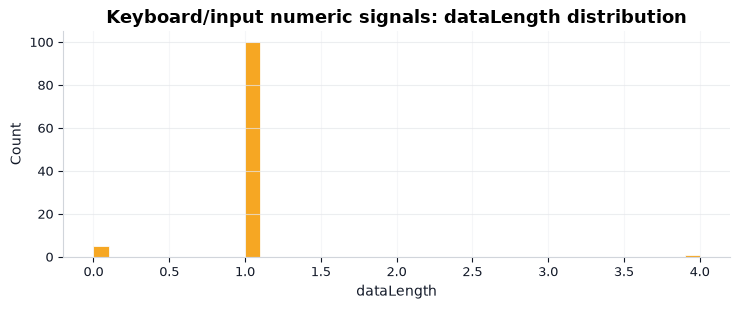

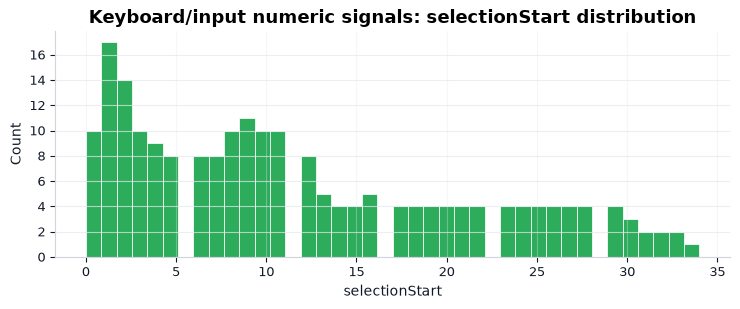

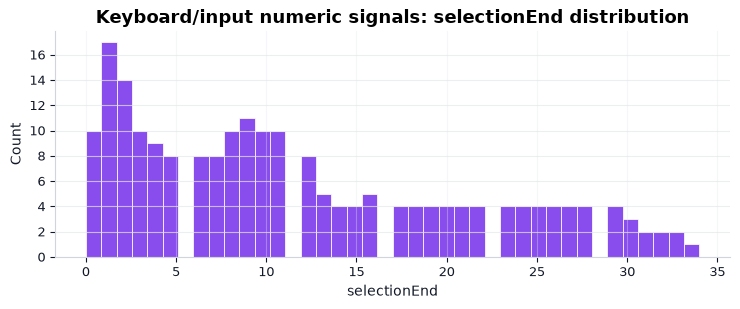

In [12]:
keyboard = fdf[fdf["kind"].isin(["keydown", "keyup", "beforeinput", "input", "select", "copy", "cut", "paste"])].copy()
print("Keyboard/input events:", len(keyboard))

if not keyboard.empty:
    kc = keyboard["kind"].value_counts().rename_axis("kind").reset_index(name="count")
    display(kc)
    kd = keyboard[keyboard["kind"] == "keydown"]
    if not kd.empty and "keyClass" in kd.columns:
        cls = kd["keyClass"].value_counts()
        fig, ax = plt.subplots(figsize=(7.5, 3.2))
        ax.bar(cls.index.astype(str), cls.values, color="#2563EB", alpha=0.92)
        ax.set_title("keydown keyClass distribution"); ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=30); polish_ax(ax)
        plt.tight_layout(); plt.show()
    plot_family(keyboard, "Keyboard/input numeric signals",
                ["valueLength", "deltaLength", "dataLength", "selectionStart", "selectionEnd"])

## Motion and orientation

Look for multi-second flat gaps (iOS pauses motion during typing/transitions) and for `alpha` drifting rather than holding a heading (relative orientation on iOS).

Device acceleration: 2440 rows


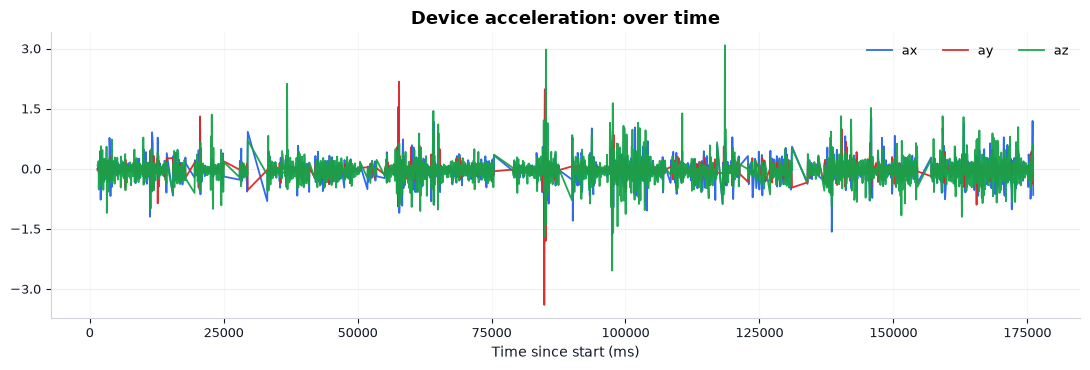

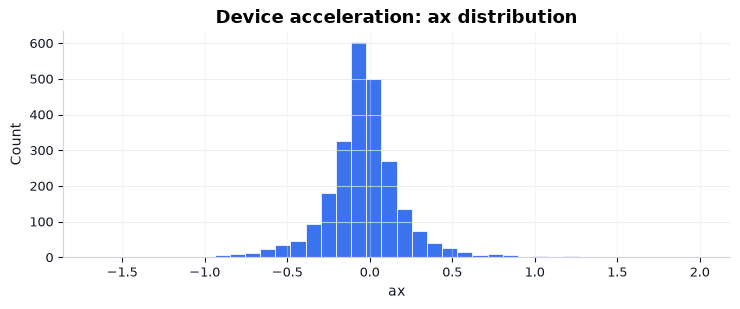

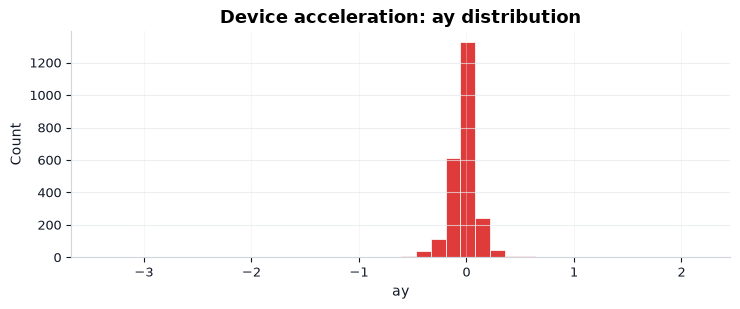

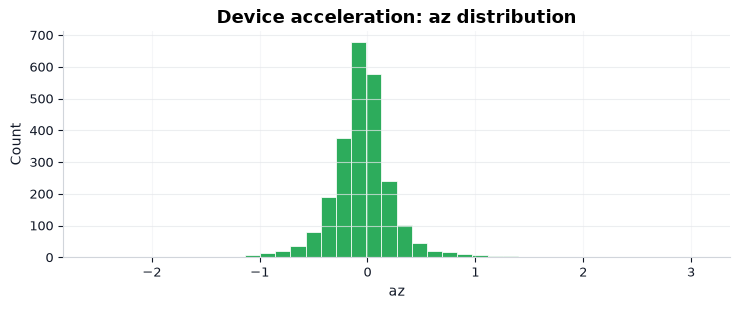

Acceleration incl. gravity: 2440 rows


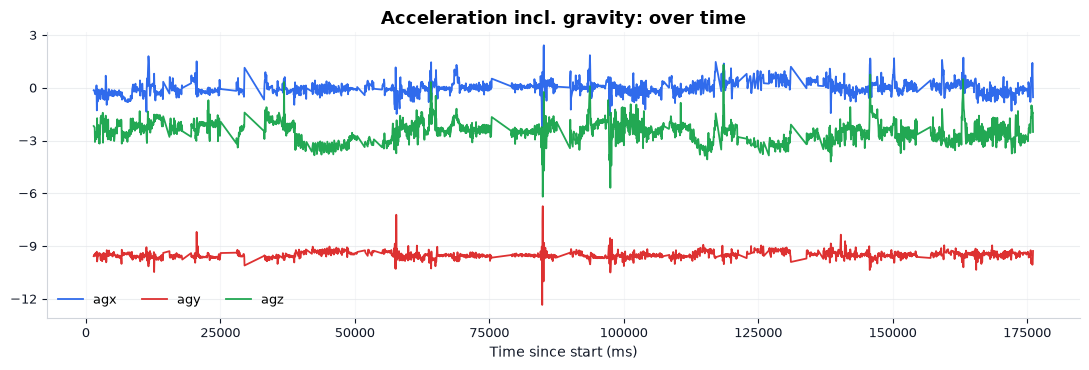

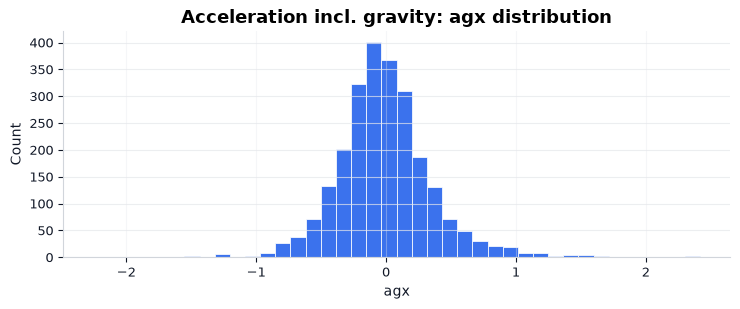

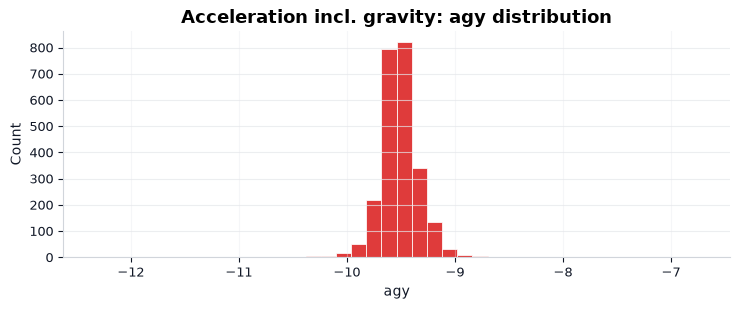

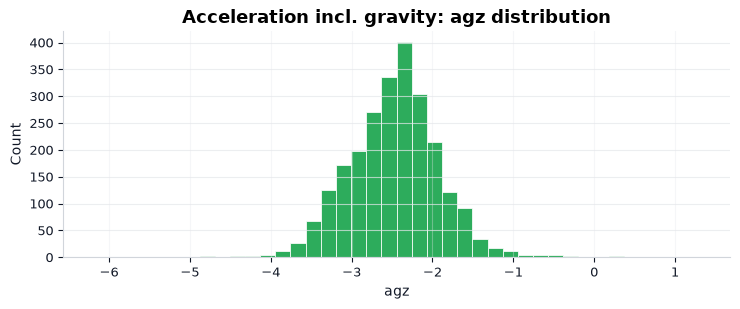

Rotation rate: 2440 rows


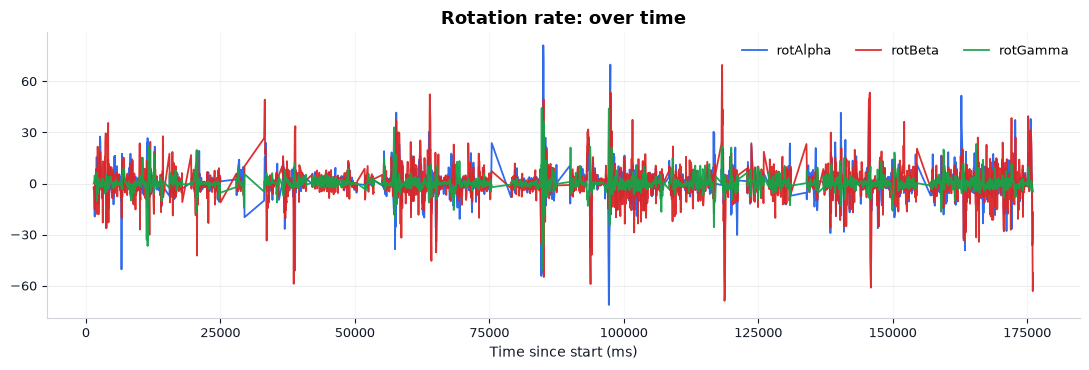

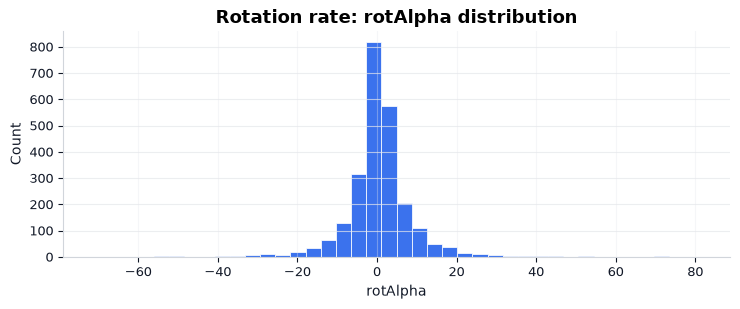

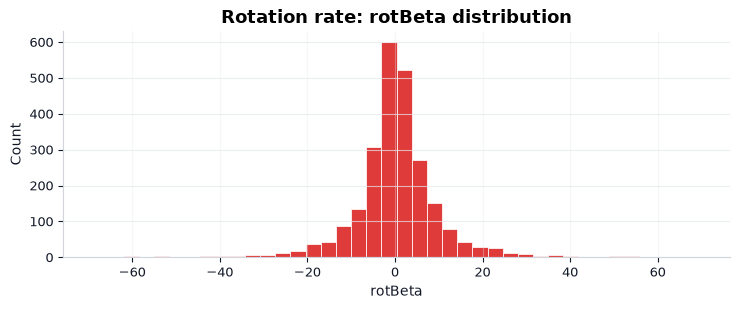

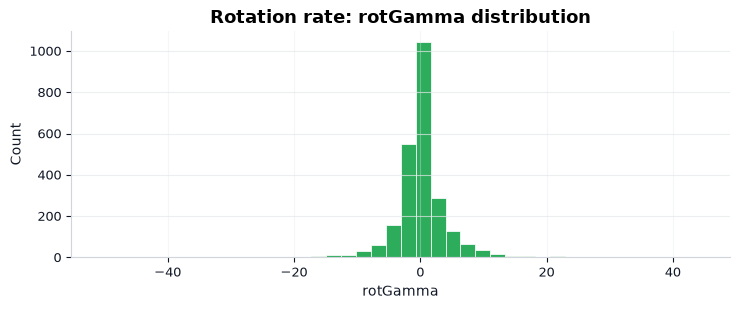

Orientation: 2425 rows


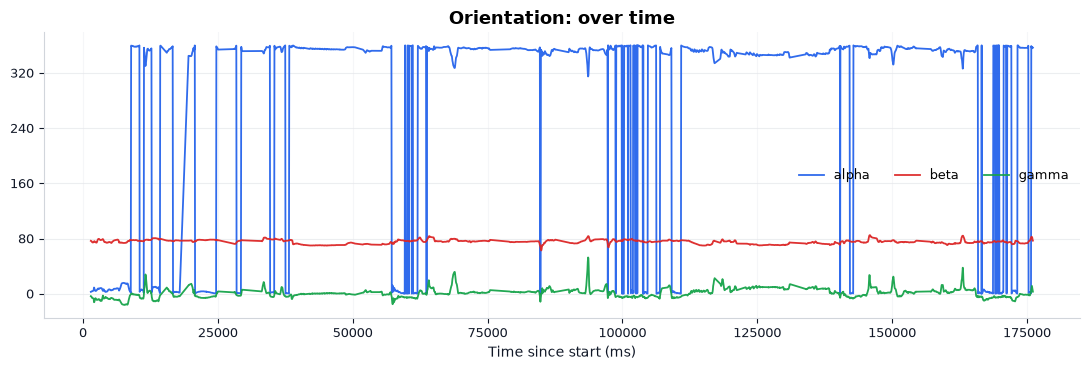

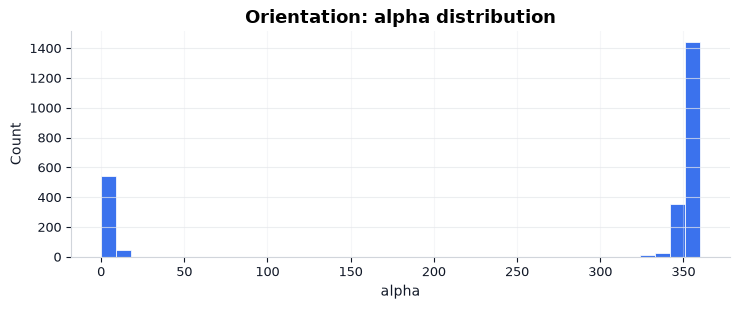

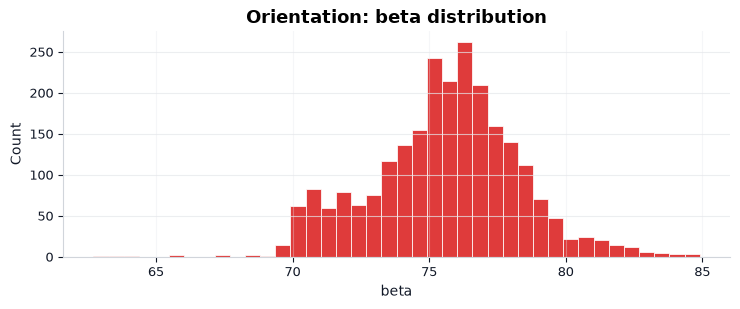

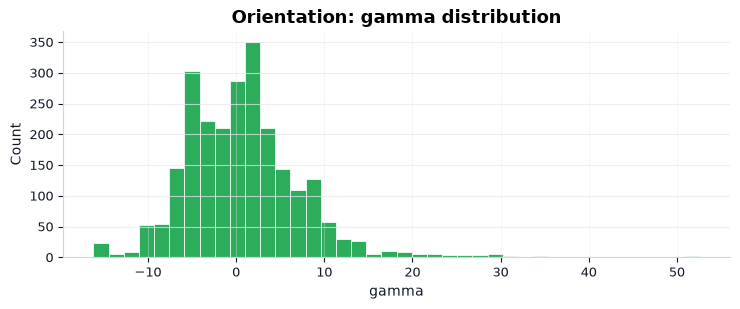

In [13]:
motion = fdf[fdf["kind"] == "devicemotion"].copy()
orientation = fdf[fdf["kind"] == "deviceorientation"].copy()

plot_family(motion, "Device acceleration", ["ax", "ay", "az"], show_table=False)
plot_family(motion, "Acceleration incl. gravity", ["agx", "agy", "agz"], show_table=False)
plot_family(motion, "Rotation rate", ["rotAlpha", "rotBeta", "rotGamma"], show_table=False)
plot_family(orientation, "Orientation", ["alpha", "beta", "gamma"], show_table=False)

### Sensor sampling gaps (dropout check)

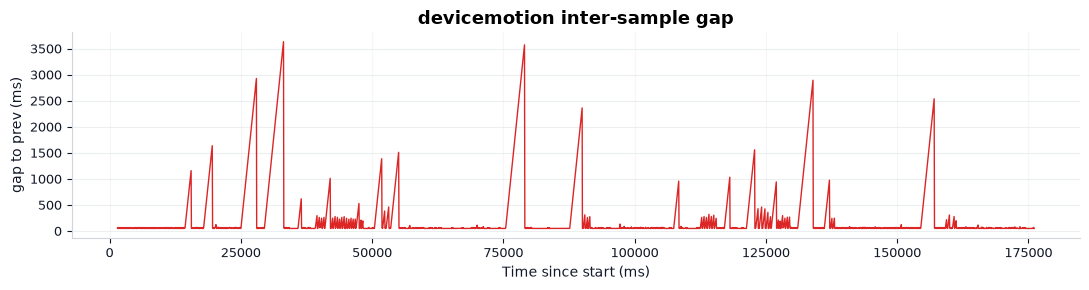

  median gap 50 ms | max gap 3634 ms


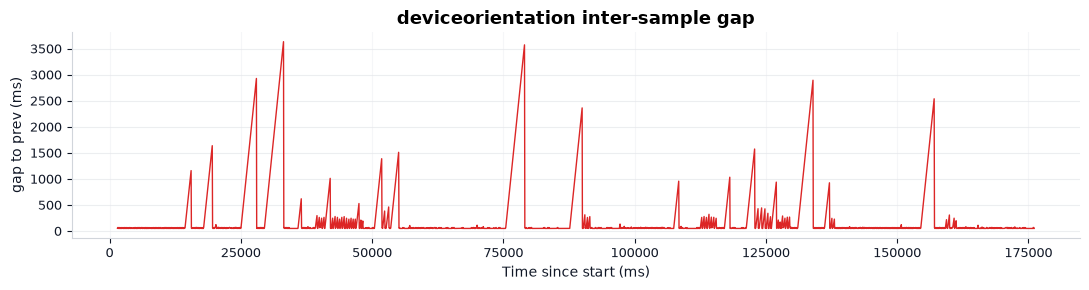

  median gap 50 ms | max gap 3634 ms


In [14]:
def gap_plot(df, title):
    if df.empty:
        print("Skipped (no data):", title); return
    d = df.sort_values("tRelMs")
    g = d["tRelMs"].diff()
    fig, ax = plt.subplots(figsize=(11, 3.0))
    ax.plot(d["tRelMs"], g, color="#DC2626", linewidth=1.0)
    ax.set_title(title); ax.set_xlabel("Time since start (ms)"); ax.set_ylabel("gap to prev (ms)")
    polish_ax(ax); plt.tight_layout(); plt.show()
    print("  median gap {:.0f} ms | max gap {:.0f} ms".format(g.median(), g.max()))

gap_plot(motion, "devicemotion inter-sample gap")
gap_plot(orientation, "deviceorientation inter-sample gap")

## Gesture summaries (discrete)

These are one-off summary events (a handful per session), so a table is more useful than a plot.

In [15]:
gest_kinds = ["gesture_drag_start", "gesture_drag_end", "pot_drag_release",
              "approval_swipe_release", "card_swipe_summary"]
gest = fdf[fdf["kind"].isin(gest_kinds)].copy()
if gest.empty:
    print("No gesture summary events in this session.")
else:
    show = ["kind", "tRelMs", "taskId", "pointerType", "samples", "distancePx", "durationMs",
            "swipeRatio", "releasedValue", "targetValue", "correctRelease",
            "selectedCard", "targetCardSelected", "maxScrollLeftRatio", "approved"]
    show = [c for c in show if c in gest.columns]
    display(gest[show].dropna(axis=1, how="all").reset_index(drop=True))

,kind,tRelMs,taskId,pointerType,samples,distancePx,durationMs,swipeRatio,releasedValue,targetValue,correctRelease,selectedCard,targetCardSelected,maxScrollLeftRatio,approved
0,gesture_drag_start,64122,pots_drag_amount_01,touch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,pot_drag_release,64999,pots_drag_amount_01,NaN,NaN,NaN,876.0,NaN,5,5,True,NaN,NaN,NaN,NaN
2,gesture_drag_end,64999,pots_drag_amount_01,touch,37.0,125.384,876.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,card_swipe_summary,79188,insights_swipe_cards_01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,food,True,0.863,NaN
4,gesture_drag_start,93673,secure_approval_01,touch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,approval_swipe_release,94033,secure_approval_01,NaN,NaN,NaN,361.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,True
6,gesture_drag_end,94033,secure_approval_01,touch,21.0,358.151,361.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,gesture_drag_start,145815,pots_drag_amount_02,touch,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,pot_drag_release,147126,pots_drag_amount_02,NaN,NaN,NaN,1310.0,NaN,11,11,True,NaN,NaN,NaN,NaN
9,gesture_drag_end,147126,pots_drag_amount_02,touch,55.0,276.911,1310.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Per-task overview & session structure

,sessionKey,taskId,taskType,taskArea,taskIndex,startedAtMs,completedAtMs,durationMs,completed,evidence
0,pG5G4MS_s42,unlock_code_01,code,secure,0,1412,4404,2992,True,"{'inputLength': 4, 'codeCorrect': True, 'corrections': 0, 'completedWithCorrectCode': True}"
1,pG5G4MS_s42,home_balance_check_01,tap_account,home,1,4405,10878,6473,True,"{'accountReviewed': True, 'selectedAccount': 'current'}"
2,pG5G4MS_s42,home_explore_cards_01,home_explore,home,2,10878,17303,6425,True,"{'exploredAccounts': ['current', 'bills', 'travel'], 'exploredCount': 3, 'allAccountsExplored': True}"
3,pG5G4MS_s42,activity_search_01,typing_search,activity,3,17304,28807,11503,True,"{'merchantMaxScrollTop': 1878, 'merchantMaxScrollTopRatio': 0.8346666666666667, 'inputLength': 4, 'targetLength': 4, 'deltaLengthLast': 1, 'corrections': 0,..."
4,pG5G4MS_s42,activity_filter_review_01,activity_filter,activity,4,28808,37847,9039,True,"{'filterSelected': 'Shopping', 'correctFilter': True}"
5,pG5G4MS_s42,activity_scroll_select_01,transaction_feed,activity,5,37847,49002,11155,True,"{'feedMaxScrollTop': 3633, 'feedMaxScrollTopRatio': 0.8351724137931035, 'selectedTarget': True, 'selectedMerchant': 'ASOS', 'selectedWhen': 'Last month', 's..."
6,pG5G4MS_s42,transaction_category_01,categorise,activity,6,49002,55910,6908,True,"{'categoryMaxScrollTop': 1234, 'categoryMaxScrollTopRatio': 0.875177304964539, 'categorySelected': True, 'category': 'Shopping', 'correctCategory': True}"
7,pG5G4MS_s42,transaction_note_01,guided_note,activity,7,55911,62575,6664,True,"{'inputLength': 13, 'targetLength': 13, 'deltaLengthLast': 1, 'corrections': 4, 'completedLength': True, 'exactMatch': True, 'exactCaseSensitiveMatch': True..."
8,pG5G4MS_s42,pots_drag_amount_01,pot_drag,pots,8,62575,66949,4374,True,"{'currentRatio': 0.41309523809523807, 'currentValue': '5', 'targetValue': '5', 'withinTolerance': True, 'dragSamples': 37, 'dragDistancePx': 125.38433162048..."
9,pG5G4MS_s42,pots_transfer_01,pots_transfer,pots,9,66949,73108,6159,True,"{'potSelected': 'travel', 'travelPotSelected': True, 'inputLength': 1, 'targetLength': 1, 'deltaLengthLast': 1, 'corrections': 0, 'completedLength': True, '..."


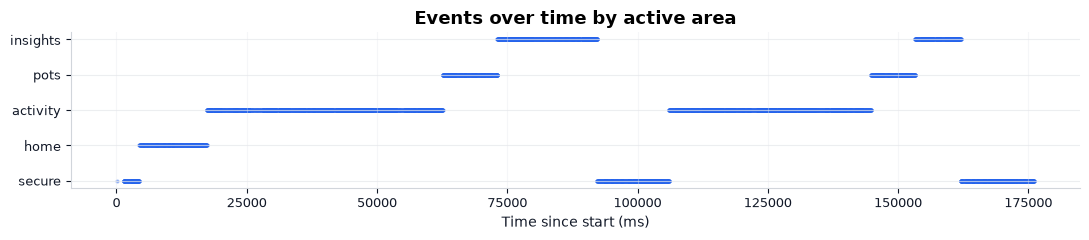

In [16]:
foc_tasks = tasks_df[tasks_df["sessionKey"] == FOCUS_SESSION] if not tasks_df.empty else tasks_df
if not foc_tasks.empty:
    display(foc_tasks.reset_index(drop=True))

# event timeline coloured by active area -> shows how the session was navigated
if not fdf.empty and "activeArea" in fdf.columns:
    areas = [a for a in fdf["activeArea"].dropna().unique()]
    ymap = {a: i for i, a in enumerate(areas)}
    fig, ax = plt.subplots(figsize=(11, max(2.5, len(areas) * 0.4)))
    ax.scatter(fdf["tRelMs"], fdf["activeArea"].map(ymap), s=4, alpha=0.35, color="#2563EB")
    ax.set_yticks(range(len(areas))); ax.set_yticklabels(areas)
    ax.set_title("Events over time by active area"); ax.set_xlabel("Time since start (ms)")
    polish_ax(ax); plt.tight_layout(); plt.show()

## Quick auto-observations

A few computed hints to point the eye; not a substitute for looking at the graphs.

In [17]:
if field_df.empty:
    print("No data loaded.")
else:
    dead = field_df[field_df["allZeroish"]][["kind", "field"]]
    print("Constant-zero (dead) fields:")
    print("  " + (", ".join("{}.{}".format(r.kind, r.field) for r in dead.itertuples()) if len(dead) else "none"))
    o = fdf[fdf["kind"] == "deviceorientation"]
    if not o.empty and "absolute" in o.columns:
        print("deviceorientation.absolute non-null:", int(o["absolute"].notna().sum()), "/", len(o), "(0 => relative-only, normal on iOS)")
    pm = int((fdf["kind"] == "pointermove").sum()); tm = int((fdf["kind"] == "touchmove").sum())
    print("pointermove vs touchmove:", pm, "vs", tm, "(touch dominates on iOS)")
    m = fdf[fdf["kind"] == "devicemotion"].sort_values("tRelMs")
    if len(m) > 2:
        g = m["tRelMs"].diff()
        print("devicemotion: {} samples, first at {:.0f} ms, max gap {:.0f} ms".format(len(m), m["tRelMs"].iloc[0], g.max()))

Constant-zero (dead) fields:
  account_card_selected.contentSetIndex, beforeinput.isComposing, focus.valueLength, keydown.repeat, keydown.ctrlKey, keydown.altKey, keydown.metaKey, nav_tab_clicked.contentSetIndex, passcode_digit_tap.contentSetIndex, pointercancel.buttons, pointercancel.x, pointercancel.y, pointercancel.xNorm, pointercancel.yNorm, pointercancel.pageX, pointercancel.pageY, pointercancel.screenX, pointercancel.screenY, pointercancel.movementX, pointercancel.movementY, pointercancel.pressure, pointercancel.tiltX, pointercancel.tiltY, pointercancel.twist, pointercancel.coalescedCount, pointerdown.button, pointerdown.movementX, pointerdown.movementY, pointerdown.pressure, pointerdown.tiltX, pointerdown.tiltY, pointerdown.twist, pointerdown.coalescedCount, pointermove.pressure, pointermove.tiltX, pointermove.tiltY, pointermove.twist, pointerup.button, pointerup.buttons, pointerup.movementX, pointerup.movementY, pointerup.pressure, pointerup.width, pointerup.height, pointerup.t